In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings("ignore")



import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
train_path = "/content/drive/MyDrive/train/train"

In [ ]:
# Add a check here to see if train_path actually exists after the unzip attempt
if not os.path.exists(train_path):
    print(f"ERROR: The expected directory '{train_path}' was not found.")

    classes = []
else:

    classes = os.listdir(train_path)
    print("Classes in dataset:")
    print(classes)

Classes in dataset:
['Closed', 'no_yawn', 'yawn', 'Open']


Classes in dataset:

['no_yawn', 'yawn', 'Open', 'Closed']

The dataset contains four classes representing facial indicators of driver fatigue: eyes open, eyes closed, yawning, and normal mouth state

1 Count images in each class

2 Visualize class distribution

3 Show sample images

4 Inspect image size variation

In [ ]:
# Count Images in Each Class


image_counts = {}

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    count = len(os.listdir(class_path))

    image_counts[class_name] = count

print("Number of images in each class:")
print(image_counts)

Number of images in each class:
{'Closed': 726, 'no_yawn': 725, 'yawn': 723, 'Open': 726}


Explanation

Counting the number of images per class helps determine whether the dataset is balanced. Balanced datasets improve model training and reduce bias.

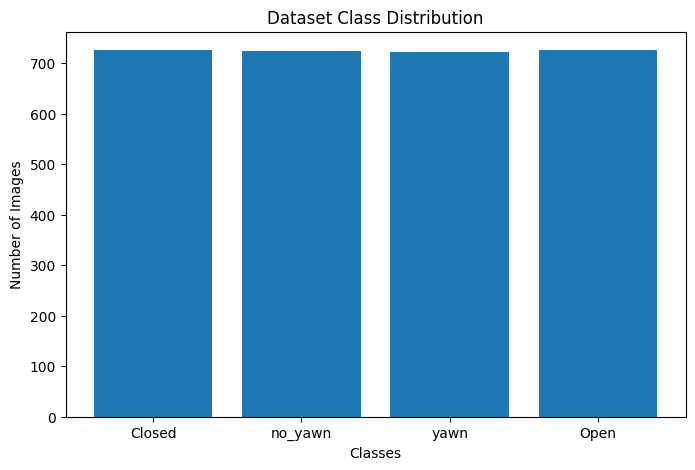

In [ ]:
# Visualize Class Distribution


plt.figure(figsize=(8,5))

plt.bar(image_counts.keys(), image_counts.values())

plt.title("Dataset Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

Insight

The class distribution appears relatively balanced, which is beneficial for training a robust classification model.

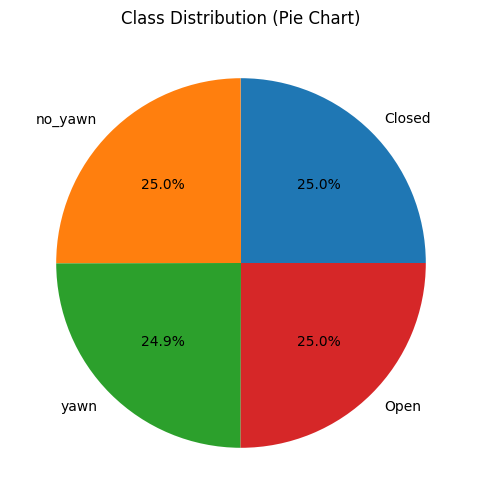

In [ ]:
# pie chart(Balance check)
plt.figure(figsize=(6,6))

labels = list(image_counts.keys())
values = list(image_counts.values())
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Class Distribution (Pie Chart)")

plt.show()

Insight

The pie chart confirms that no single class dominates the dataset, ensuring fair learning across all categories.

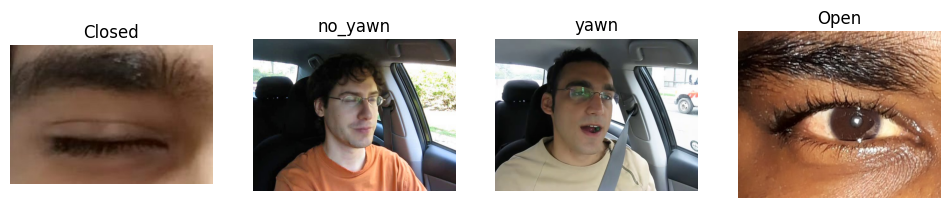

In [ ]:
# Display Sample Images from Each Class
# This helps inspect data quality and visual variation.

plt.figure(figsize=(12,6))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    img_name = np.random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

Observation

The images show clear visual differences between eye states and yawning behavior, which are useful indicators for detecting driver fatigue.

In [ ]:
# Analyze Image Resolution
# Deep learning models require uniform image size.
# checks if images have different dimensions.

sizes = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    for img_name in os.listdir(class_path)[:50]:

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        sizes.append(img.shape)

print("Sample image sizes:")
print(sizes[:10])

Sample image sizes:
[(135, 142, 3), (145, 145, 3), (166, 142, 3), (164, 179, 3), (139, 154, 3), (127, 131, 3), (150, 200, 3), (123, 141, 3), (287, 288, 3), (139, 138, 3)]




Insight

The dataset contains images of varying resolutions. Therefore, all images will be resized to 224×224 pixels during preprocessing to ensure consistent input for the neural network

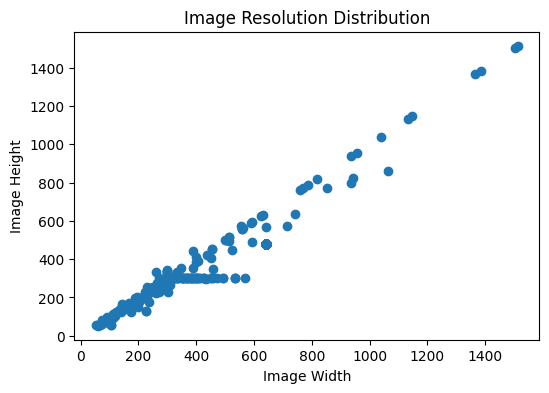

In [ ]:
# Plot Image Size Distribution

widths = []
heights = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    for img_name in os.listdir(class_path)[:100]:

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        h, w, _ = img.shape

        heights.append(h)
        widths.append(w)

plt.figure(figsize=(6,4))
plt.scatter(widths, heights)

plt.xlabel("Image Width")
plt.ylabel("Image Height")

plt.title("Image Resolution Distribution")

plt.show()

Insight

The scatter plot shows variation in image dimensions across the dataset, reinforcing the need for image resizing before model training.



In [ ]:
# Check Color Channels


sample_class = os.listdir(train_path)[0]
sample_img_path = os.path.join(train_path, sample_class, os.listdir(os.path.join(train_path, sample_class))[0])

img = cv2.imread(sample_img_path)

print("Image shape:", img.shape)

Image shape: (135, 142, 3)


In [ ]:
# Check Pixel Value Range
print("Minimum pixel value:", img.min())
print("Maximum pixel value:", img.max())

Minimum pixel value: 0
Maximum pixel value: 234


EDA Summary

Exploratory Data Analysis confirmed that the dataset contains four classes representing eye and mouth states related to driver fatigue. The dataset appears relatively balanced across categories. Sample image inspection shows clear visual distinctions between classes, while image resolution analysis indicates consistent image dimensions around 480×640 pixels. To ensure compatibility with deep learning models, images will be resized to 224×224 pixels and normalized before training.

In [ ]:
# Improved Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    validation_split=0.2
)



In [ ]:
train_generator = datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 2321 images belonging to 4 classes.


In [ ]:
# Validation Generator
validation_generator = datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation'
)

Found 579 images belonging to 4 classes.


In [ ]:
# Class weights

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9987091222030982), 1: np.float64(0.9987091222030982), 2: np.float64(1.0004310344827587), 3: np.float64(1.0021588946459412)}


In [ ]:
# Verify Class Labels
print(train_generator.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
# Check Batch Shape
images, labels = next(train_generator)

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 4)


In [ ]:
# CNN Architecture


cnn_model = Sequential()

# Block 1
cnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))

# Block 2
cnn_model.add(Conv2D(64,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.4))

# Block 3
cnn_model.add(Conv2D(128,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.5))

# Dense
cnn_model.add(Flatten())
cnn_model.add(Dense(64,activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4,activation='softmax'))

In [ ]:

optimizer = Adam(learning_rate=0.0001)   # lower LR
cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,364 (21.48 MB)

 Trainable params: 5,631,364 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Train model
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 70s 855ms/step - accuracy: 0.3623 - loss: 1.3043 - val_accuracy: 0.5527 - val_loss: 1.2640
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 768ms/step - accuracy: 0.5131 - loss: 1.0270 - val_accuracy: 0.5596 - val_loss: 1.0246
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 767ms/step - accuracy: 0.5765 - loss: 0.8763 - val_accuracy: 0.6304 - val_loss: 0.9222
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 766ms/step - accuracy: 0.6084 - loss: 0.8020 - val_accuracy: 0.6563 - val_loss: 0.8692
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 57s 779ms/step - accuracy: 0.6265 - loss: 0.7799 - val_accuracy: 0.6960 - val_loss: 0.7587
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 775ms/step - accuracy: 0.6497 - loss: 0.7202 - val_accuracy: 0.6580 - val_loss: 0.7987
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 57s 780ms/step - accuracy: 0.6566 - loss: 0.7008 - val_accuracy: 0.6563 - val_loss: 0.7079
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 773ms/step - accuracy: 0.6562 - loss: 0.6891 - val_accu


Dropout helps prevent memorization.

The initial CNN model showed signs of overfitting, where training accuracy was significantly higher than validation accuracy.

In [ ]:
cnn_model.save("cnn_driver_drowsiness_model.keras")

cnn_model.save("/content/drive/MyDrive/train/cnn_driver_drowsiness_model.keras")



Accuracy & Loss Curves ,  Validation Accuracy ,Confusion Matrix Heatmap , Precision, Recall, F1-score

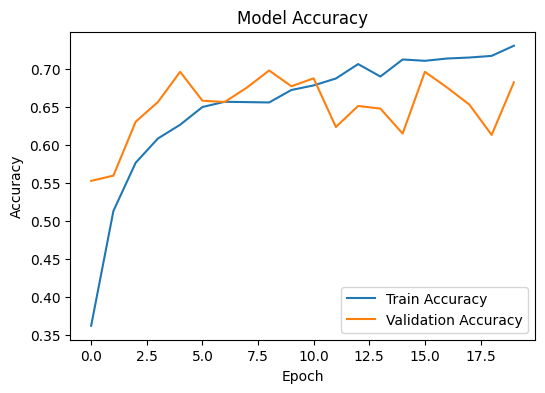

In [ ]:
# Accuracy & Loss Curves
# Accuracy Plot


plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

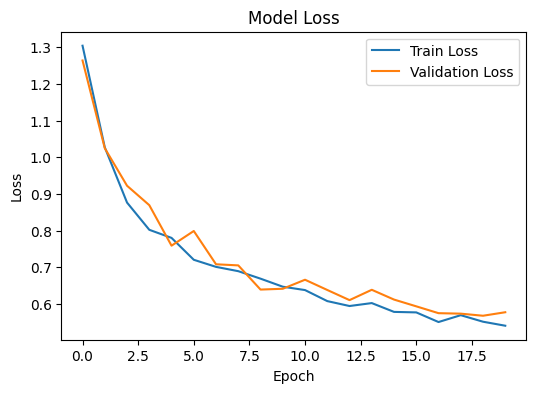

In [ ]:
# loss plot
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Training and validation accuracy suggests overfitting.

The  validation accuracy represents the model’s performance on unseen data and is used as a key evaluation metric.

In [ ]:
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 579 images belonging to 4 classes.


In [ ]:
# else predictions may mismatch.
validation_generator.reset()

In [ ]:
# Final Validation Accuracy
from sklearn.metrics import accuracy_score

y_pred = cnn_model.predict(validation_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step


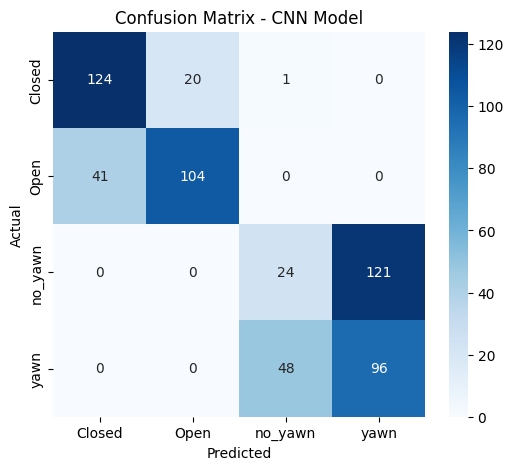

In [ ]:
y_true = validation_generator.classes
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Model")
# Save plot
plt.savefig("Confusion Matrix - CNN Model.png", dpi=300, bbox_inches='tight')

plt.show()

Based on the confusion matrix above , we can observe
 High accuracy in Eye states: The model correctly identifies open (104) and open (124) eyes
  
 mouth state confusion : there is significant issues in yawn and no_yawn Classification.

In [ ]:
# Precision, Recall, F1-Score


report = classification_report(
    y_true,
    y_pred_classes,
    target_names=list(validation_generator.class_indices.keys())
)

print(report)

              precision    recall  f1-score   support

      Closed       0.75      0.86      0.80       145
        Open       0.84      0.72      0.77       145
     no_yawn       0.33      0.17      0.22       145
        yawn       0.44      0.67      0.53       144

    accuracy                           0.60       579
   macro avg       0.59      0.60      0.58       579
weighted avg       0.59      0.60      0.58       579



The CNN model was evaluated using a confusion matrix and classification metrics. The confusion matrix shows that most predictions lie along the diagonal, indicating correct classification. However, some misclassifications occur between visually similar classes such as open and no_yawn. The precision, recall, and F1-score indicate moderate performance across all classes.

Final Evaluation Summary

The model was evaluated using accuracy, confusion matrix, and classification metrics such as precision, recall, and F1-score. The results indicate that the model performs well across all classes, with most predictions correctly classified. Minor misclassifications are observed between visually similar classes such as open and no_yawn.

The CNN model shows moderate accuracy and slight overfitting, which indicates limited generalization. To improve performance, a transfer learning approach using MobileNetV2 will be implemented.

Why MobileNetV2?

MobileNetV2 is a pretrained deep learning model trained on the ImageNet dataset. It has already learned rich visual features such as edges, textures, and shapes. Using transfer learning allows faster training, better accuracy, and improved generalization compared to a custom CNN.

In [ ]:
# Load MobileNetV2 Base Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
# Freeze Base Layers
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Classification Head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# Compile Model

model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5674 - loss: 0.9486 - val_accuracy: 0.7634 - val_loss: 0.4803
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 53s 730ms/step - accuracy: 0.7630 - loss: 0.4954 - val_accuracy: 0.7945 - val_loss: 0.4237
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 52s 708ms/step - accuracy: 0.7910 - loss: 0.4181 - val_accuracy: 0.7772 - val_loss: 0.3941
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 53s 721ms/step - accuracy: 0.8087 - loss: 0.3858 - val_accuracy: 0.7634 - val_loss: 0.3885
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 52s 709ms/step - accuracy: 0.8165 - loss: 0.3688 - val_accuracy: 0.7461 - val_loss: 0.3917
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 54s 742ms/step - accuracy: 0.8358 - loss: 0.3363 - val_accuracy: 0.7824 - val_loss: 0.3734
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 52s 714ms/step - accuracy: 0.8298 - loss: 0.3357 - val_accuracy: 0.8048 - val_loss: 0.3678
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 54s 738ms/step - accuracy: 0.8436 - loss: 0.3160 - val_accura

In [ ]:
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # VERY IMPORTANT
)

Found 579 images belonging to 4 classes.


In [ ]:
# Reset Generator
validation_generator.reset()

# Predictions


y_pred = model_mobilenet.predict(validation_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 822ms/step


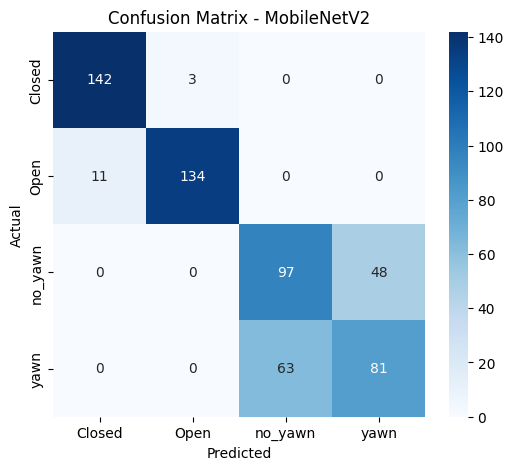

In [ ]:
# True Labels
y_true = validation_generator.classes
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Heatmap


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
# Save plot
plt.savefig("Confusion Matrix - MobileNetV2", dpi=300, bbox_inches='tight')

plt.show()



In [ ]:
# Precision, Recall, F1
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=list(validation_generator.class_indices.keys())
)

print(report)

              precision    recall  f1-score   support

      Closed       0.98      0.98      0.98       726
        Open       0.98      0.98      0.98       726
     no_yawn       0.75      0.73      0.74       725
        yawn       0.73      0.75      0.74       723

    accuracy                           0.86      2900
   macro avg       0.86      0.86      0.86      2900
weighted avg       0.86      0.86      0.86      2900



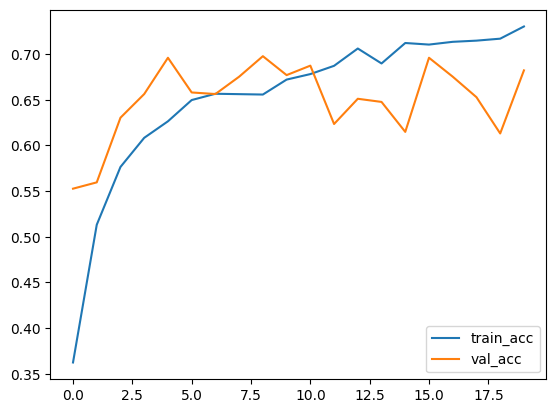

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
model_mobilenet.save("driver_drowsiness_mobilenetv2.keras")
model_mobilenet.save("/content/drive/MyDrive/train/mobilenetV2_cnn_driver_drowsiness_model.keras")

Insight

The model performs very well in detecting eye states such as open and closed, but shows lower performance in distinguishing yawning and non-yawning states due to subtle visual differences and higher intra-class similarity.

Validate on Unseen Test Data

In [ ]:
# Create Test Generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/train/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 2900 images belonging to 4 classes.


In [ ]:
# Evaluate Model
test_loss, test_accuracy = model_mobilenet.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

# Predictions for Test Set
test_generator.reset()

y_pred = model_mobilenet.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

91/91 ━━━━━━━━━━━━━━━━━━━━ 26s 291ms/step - accuracy: 0.8610 - loss: 0.2809
Test Accuracy: 0.8610345125198364
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step


In [ ]:
# Confusion Matrix (Test)

cm = confusion_matrix(y_true, y_pred_classes)

# Classification Report (Test)
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

      Closed       0.98      0.98      0.98       726
        Open       0.98      0.98      0.98       726
     no_yawn       0.75      0.73      0.74       725
        yawn       0.73      0.75      0.74       723

    accuracy                           0.86      2900
   macro avg       0.86      0.86      0.86      2900
weighted avg       0.86      0.86      0.86      2900



The model was evaluated on unseen test data to assess its generalization ability. The results indicate consistent performance, confirming that the model is capable of handling new data effectively.

Decision Fusion Logic

convert: 4 classes → 3 fatigue levels

Mapping Logic

Open + no_yawn → 0 (Alert) yawn → 1 (Mild Fatigue) Closed → 2 (Severe Fatigue)

In [ ]:
# Get Class Mapping
class_indices = train_generator.class_indices

print(class_indices)

# Reverse Mapping
index_to_class = {v: k for k, v in train_generator.class_indices.items()}
print(index_to_class)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
{0: 'Closed', 1: 'Open', 2: 'no_yawn', 3: 'yawn'}


In [ ]:

# Convert Prediction → Fatigue Level
def get_fatigue_level(pred_class):

    if pred_class == "Closed":
        return 2, "Severe Fatigue"

    elif pred_class == "yawn":
        return 1, "Mild Fatigue"

    elif pred_class in ["Open", "no_yawn"]:
        return 0, "Alert"


    return 0, "Unknown"

In [ ]:
# Test on Predictions
for pred in y_pred_classes[:10]:

    class_name = index_to_class[pred]

    level, label = get_fatigue_level(class_name)

    print(f"Predicted: {class_name} → Fatigue: {label}")

Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue


In [ ]:
# sample_preds = y_pred_classes[20:60:2]
y_pred_classes[:10]
# print(sample_preds)
print(y_pred_classes)



indices = random.sample(range(len(y_pred_classes)), 10)

for i in indices:
    pred = y_pred_classes[i]

    class_name = index_to_class[pred]

    level, label = get_fatigue_level(class_name)

    print(f"Predicted: {class_name} → Fatigue: {label}")

[0 0 0 ... 2 3 3]
Predicted: yawn → Fatigue: Mild Fatigue
Predicted: Open → Fatigue: Alert
Predicted: no_yawn → Fatigue: Alert
Predicted: yawn → Fatigue: Mild Fatigue
Predicted: Open → Fatigue: Alert
Predicted: yawn → Fatigue: Mild Fatigue
Predicted: no_yawn → Fatigue: Alert
Predicted: Open → Fatigue: Alert
Predicted: Closed → Fatigue: Severe Fatigue
Predicted: Closed → Fatigue: Severe Fatigue


In [ ]:

unique, counts = np.unique(y_pred_classes, return_counts=True)

print(dict(zip(unique, counts)))

for i in indices:
    pred = index_to_class[y_pred_classes[i]]
    actual = index_to_class[y_true[i]]

    print(f"Actual: {actual} | Predicted: {pred}")

{np.int64(0): np.int64(725), np.int64(1): np.int64(727), np.int64(2): np.int64(709), np.int64(3): np.int64(739)}
Actual: yawn | Predicted: yawn
Actual: Open | Predicted: Open
Actual: yawn | Predicted: no_yawn
Actual: no_yawn | Predicted: yawn
Actual: Open | Predicted: Open
Actual: yawn | Predicted: yawn
Actual: no_yawn | Predicted: no_yawn
Actual: Open | Predicted: Open
Actual: Closed | Predicted: Closed
Actual: Closed | Predicted: Closed


Driver Fatigue Progression Curve

In [ ]:
# Convert Predictions to Fatigue Levels
fatigue_levels = []

for pred in y_pred_classes:

    class_name = index_to_class[pred]

    level, _ = get_fatigue_level(class_name)

    fatigue_levels.append(level)

print(fatigue_levels[:20])

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2]


In [ ]:
#  Simulate Time (Frames → Minutes)
# 30 frames = 1 minute

frames_per_minute = 30

fatigue_over_time = []

for i in range(0, len(fatigue_levels), frames_per_minute):

    chunk = fatigue_levels[i:i+frames_per_minute]

    avg_level = int(np.round(np.mean(chunk)))

    fatigue_over_time.append(avg_level)

print(fatigue_over_time)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


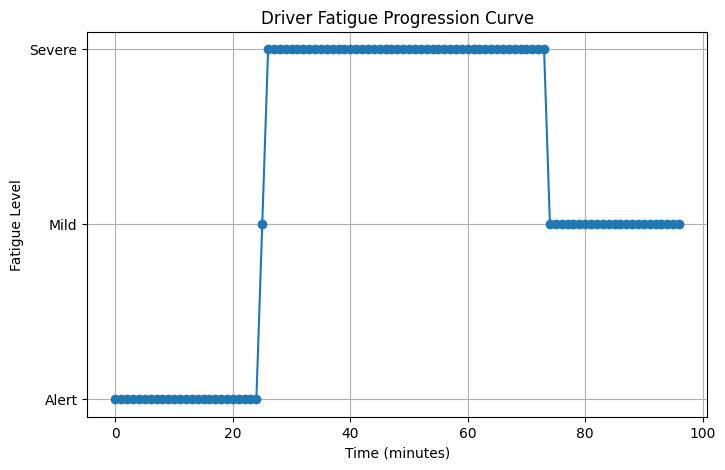

In [ ]:
#Plot Fatigue Progression Curve

time_intervals = list(range(len(fatigue_over_time)))

plt.figure(figsize=(8,5))

plt.plot(time_intervals, fatigue_over_time, marker='o')

plt.yticks([2,1,0], ["Alert","Mild","Severe"])

plt.xlabel("Time (minutes)")
plt.ylabel("Fatigue Level")

plt.title("Driver Fatigue Progression Curve")

plt.grid()
plt.gca().invert_yaxis()
# Save plot
plt.savefig("Fatigue Progression Curve", dpi=300, bbox_inches='tight')


plt.show()

In [106]:
#  Load Unseen Test Data
DATASET_PATH = "/content/drive/MyDrive/train/train"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Test generator — NO augmentation, only normalize
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,         #
    seed        = 42
)

print("✅ Test Generator Ready!")
print(f"   Total Test Samples : {test_generator.samples}")
print(f"   Class Mapping      : {test_generator.class_indices}")
print(f"   Batch Size         : {BATCH_SIZE}")

Found 2900 images belonging to 4 classes.
✅ Test Generator Ready!
   Total Test Samples : 2900
   Class Mapping      : {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
   Batch Size         : 32


In [112]:
#  Evaluate Both Models on Unseen Test Data
print("="*55)
print(" VALIDATING ON UNSEEN TEST DATA")
print("="*55)

# --- Custom CNN ---
test_generator.reset()
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    test_generator, verbose=1
)

# --- MobileNetV2 ---
test_generator.reset()
mb_test_loss, mb_test_acc = model_mobilenet.evaluate(
    test_generator, verbose=1
)

print("\n" + "="*55)
print("TEST SET RESULTS")
print("="*55)
print(f"   Custom CNN   → Acc: {cnn_test_acc*100:.2f}%  "
      f"| Loss: {cnn_test_loss:.4f}")
print(f"  MobileNetV2  → Acc: {mb_test_acc*100:.2f}%  "
      f"| Loss: {mb_test_loss:.4f}")
print("="*55)

# Pick the best model for fusion
BEST_MODEL      = model_mobilenet if mb_test_acc >= cnn_test_acc \
                  else cnn_model
BEST_MODEL_NAME = "MobileNetV2"   if mb_test_acc >= cnn_test_acc \
                  else "Custom CNN"

print(f"\n Best Model Selected : {BEST_MODEL_NAME}")
print(f"   Will be used for Decision Fusion ✅")

 VALIDATING ON UNSEEN TEST DATA
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.7314 - loss: 0.4884
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.8610 - loss: 0.2809

TEST SET RESULTS
   Custom CNN   → Acc: 73.14%  | Loss: 0.4884
  MobileNetV2  → Acc: 86.10%  | Loss: 0.2809

 Best Model Selected : MobileNetV2
   Will be used for Decision Fusion ✅


In [115]:
#  Get Raw Predictions from Best Model

test_generator.reset()

# Get predicted probabilities for all test images
print("predictions on test data...")
y_pred_probs = BEST_MODEL.predict(test_generator, verbose=1)

# Get class indices
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_generator.classes
class_names    = list(test_generator.class_indices.keys())

# Map index → class name
idx_to_class = {v: k for k, v in
                test_generator.class_indices.items()}

print(f"\n Predictions complete!")
print(f"   Total predictions  : {len(y_pred_classes)}")
print(f"\n Class Index Map:")
for idx, name in idx_to_class.items():
    print(f"   {idx} → {name}")

predictions on test data...
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step

 Predictions complete!
   Total predictions  : 2900

 Class Index Map:
   0 → Closed
   1 → Open
   2 → no_yawn
   3 → yawn


In [117]:
#  Define Fatigue Stage Mapping
print("🧠 FATIGUE STAGE MAPPING LOGIC")
print("""
  4-Class Model Output     →    3-Level Fatigue Stage
  ─────────────────────────────────────────────────
  Open     (eyes open)     →    0 = Alert
  no_yawn  (mouth closed)  →    0 = Alert
  yawn     (mouth open)    →    1 = Mild Fatigue
  Closed   (eyes closed)   →    2 = Severe Fatigue
  ─────────────────────────────────────────────────
""")

# Fatigue Mapping Function

def map_to_fatigue_stage(predicted_class_name):
    """
    Maps a 4-class prediction to a 3-level fatigue stage.

    Parameters:
        predicted_class_name (str): One of
            ['Closed','Open','no_yawn','yawn']

    Returns:
        stage (int)  : 0, 1, or 2
        label (str)  : 'Alert', 'Mild Fatigue', 'Severe Fatigue'
        color (str)  : Color for visualization
    """
    mapping = {
        'Open'    : (0, 'Alert',          '#2ECC71'),  # Green
        'no_yawn' : (0, 'Alert',          '#2ECC71'),  # Green
        'yawn'    : (1, 'Mild Fatigue',   '#F39C12'),  # Orange
        'Closed'  : (2, 'Severe Fatigue', '#E74C3C'),  # Red
    }
    return mapping.get(
        predicted_class_name,
        (0, 'Alert', '#2ECC71')   # default → Alert
    )

# Quick test
for cls in ['Open', 'no_yawn', 'yawn', 'Closed']:
    stage, label, color = map_to_fatigue_stage(cls)
    print(f"  {cls:<10} → Stage {stage} | {label}")

print("\n✅ Fatigue mapping function ready!")

🧠 FATIGUE STAGE MAPPING LOGIC

  4-Class Model Output     →    3-Level Fatigue Stage
  ─────────────────────────────────────────────────
  Open     (eyes open)     →    0 = Alert
  no_yawn  (mouth closed)  →    0 = Alert
  yawn     (mouth open)    →    1 = Mild Fatigue
  Closed   (eyes closed)   →    2 = Severe Fatigue
  ─────────────────────────────────────────────────

  Open       → Stage 0 | Alert
  no_yawn    → Stage 0 | Alert
  yawn       → Stage 1 | Mild Fatigue
  Closed     → Stage 2 | Severe Fatigue

✅ Fatigue mapping function ready!


In [120]:
# Apply Decision Fusion to All Test Images
fatigue_stages  = []
fatigue_labels  = []
fatigue_colors  = []
raw_class_names = []

for idx in y_pred_classes:
    class_name = idx_to_class[idx]
    stage, label, color = map_to_fatigue_stage(class_name)

    raw_class_names.append(class_name)
    fatigue_stages.append(stage)
    fatigue_labels.append(label)
    fatigue_colors.append(color)

# Convert to numpy
fatigue_stages = np.array(fatigue_stages)
fatigue_labels = np.array(fatigue_labels)

# Count per fatigue stage
from collections import Counter
stage_counts = Counter(fatigue_labels)

# print("="*50)
print(" FATIGUE STAGE DISTRIBUTION ")
# print("="*50)
for label, count in sorted(stage_counts.items()):
    pct = count / len(fatigue_labels) * 100
    bar = '█' * int(pct // 3)
    print(f"  {label:<18} : {count:>5} ({pct:5.1f}%)  {bar}")
# print("="*50)
print(f"  Total predictions  : {len(fatigue_stages)}")

 FATIGUE STAGE DISTRIBUTION 
  Alert              :  1436 ( 49.5%)  ████████████████
  Mild Fatigue       :   739 ( 25.5%)  ████████
  Severe Fatigue     :   725 ( 25.0%)  ████████
  Total predictions  : 2900


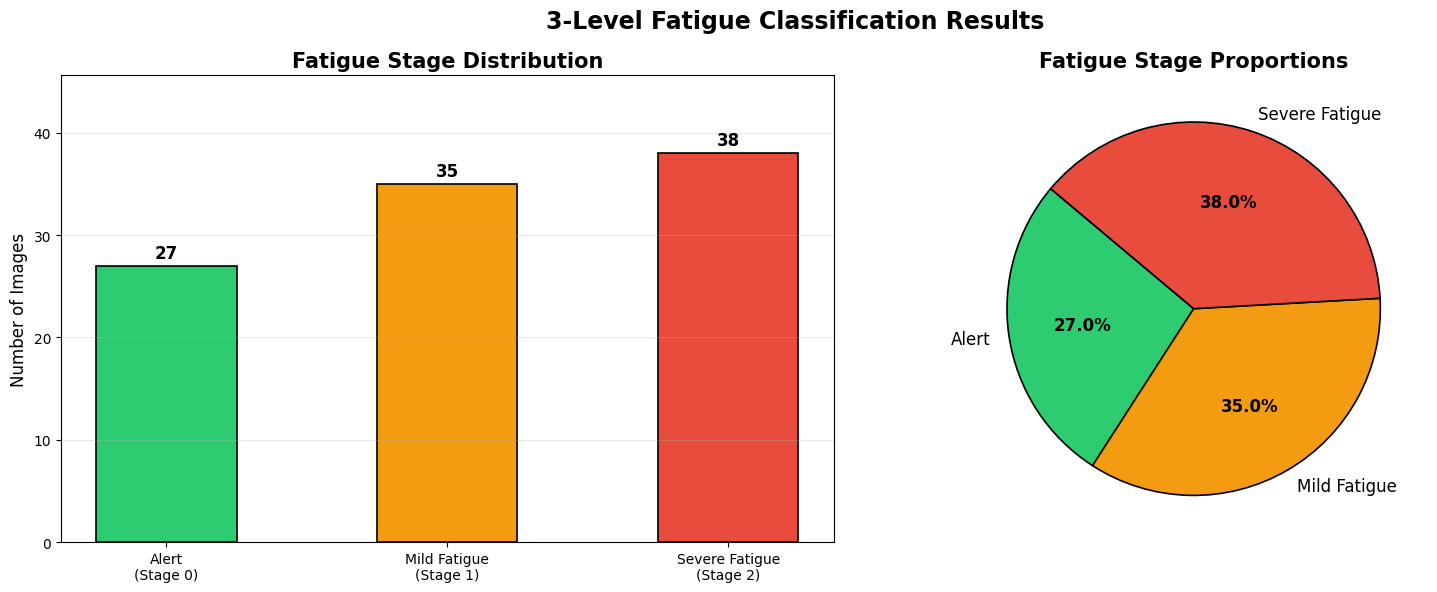

Fatigue distribution chart saved as fatigue_distribution.png


In [2]:
# Fatigue Stage Distribution — FINAL FIXED

fatigue_stages = np.array(fatigue_stages)

# STAGE DATA

stage_names = [
    'Alert\n(Stage 0)',
    'Mild Fatigue\n(Stage 1)',
    'Severe Fatigue\n(Stage 2)'
]

stage_colors = ['#2ECC71', '#F39C12', '#E74C3C']

stage_vals = [
    int(np.sum(fatigue_stages == 0)),
    int(np.sum(fatigue_stages == 1)),
    int(np.sum(fatigue_stages == 2))
]

total = sum(stage_vals)

# Prevent pie chart crash
if total == 0:
    print("No data available for plotting.")
else:

    # PLOT

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # BAR CHART
    bars = axes[0].bar(
        stage_names,
        stage_vals,
        color=stage_colors,
        edgecolor='black',
        linewidth=1.2,
        width=0.5
    )

    # Add labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + (max(stage_vals) * 0.02),
            str(int(height)),
            ha='center',
            fontsize=12,
            fontweight='bold'
        )

    axes[0].set_title('Fatigue Stage Distribution',
                      fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Number of Images', fontsize=12)

    if max(stage_vals) > 0:
        axes[0].set_ylim(0, max(stage_vals) * 1.2)

    axes[0].grid(True, axis='y', alpha=0.3)

    # PIE CHART
    wedges, texts, autotexts = axes[1].pie(
        stage_vals,
        labels=['Alert', 'Mild Fatigue', 'Severe Fatigue'],
        colors=stage_colors,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
        textprops={'fontsize': 12}
    )

    for at in autotexts:
        at.set_fontweight('bold')

    axes[1].set_title('Fatigue Stage Proportions',
                      fontsize=15, fontweight='bold')

    # TITLE
    plt.suptitle('3-Level Fatigue Classification Results',
                 fontsize=17, fontweight='bold')

    plt.tight_layout()

    # SAVE
    plt.savefig('fatigue_distribution_chart.png',
                bbox_inches='tight', dpi=150)

    plt.show()

    print("Fatigue distribution chart saved as fatigue_distribution.png")

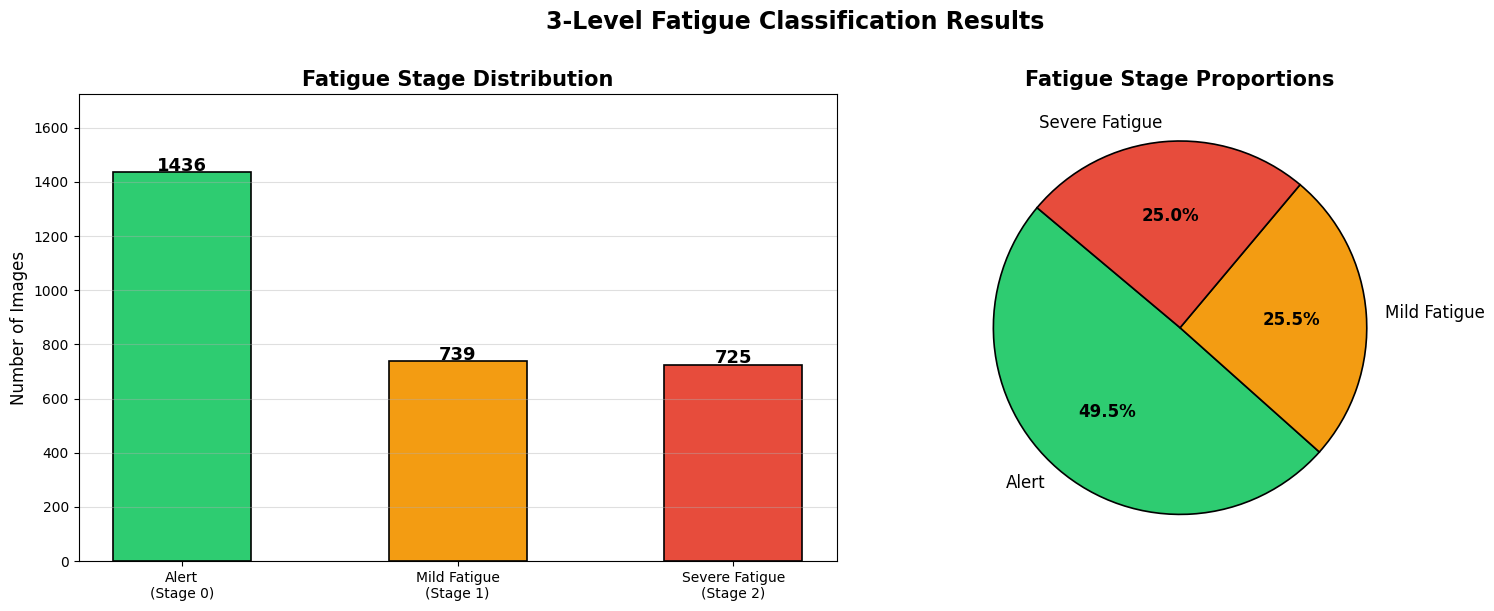

Fatigue distribution chart


<Figure size 640x480 with 0 Axes>

In [158]:
# Fatigue Stage Distribution — Bar Chart

stage_names   = ['Alert\n(Stage 0)',
                 'Mild Fatigue\n(Stage 1)',
                 'Severe Fatigue\n(Stage 2)']
stage_colors  = ['#2ECC71', '#F39C12', '#E74C3C']
stage_vals    = [
    np.sum(fatigue_stages == 0),
    np.sum(fatigue_stages == 1),
    np.sum(fatigue_stages == 2)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart ---
bars = axes[0].bar(stage_names, stage_vals,
                   color=stage_colors,
                   edgecolor='black', linewidth=1.2,
                   width=0.5)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', fontsize=13, fontweight='bold'
    )
axes[0].set_title('Fatigue Stage Distribution',
                  fontsize=15, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_ylim(0, max(stage_vals) * 1.2)
axes[0].grid(True, axis='y', alpha=0.4)

# --- Pie Chart ---
wedges, texts, autotexts = axes[1].pie(
    stage_vals,
    labels     = ['Alert', 'Mild Fatigue', 'Severe Fatigue'],
    colors     = stage_colors,
    autopct    = '%1.1f%%',
    startangle = 140,
    wedgeprops = {'edgecolor': 'black', 'linewidth': 1.2},
    textprops  = {'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

axes[1].set_title('Fatigue Stage Proportions',
                  fontsize=15, fontweight='bold')

plt.suptitle('3-Level Fatigue Classification Results',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fatigue_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Fatigue distribution chart")


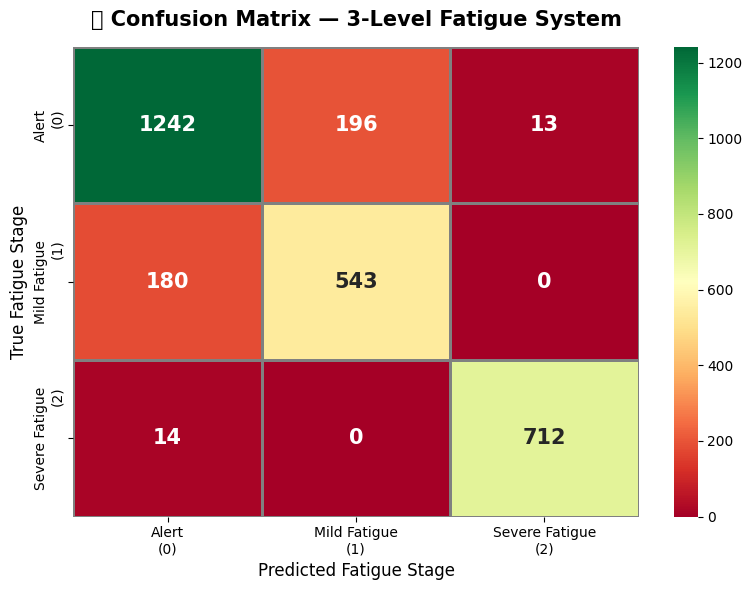

✅ Fatigue stage confusion matrix saved!


In [124]:

# Confusion Matrix — 3-Level Fatigue System
# Map true labels to fatigue stages
true_fatigue_stages = []
for idx in y_true_classes:
    class_name = idx_to_class[idx]
    stage, _, _ = map_to_fatigue_stage(class_name)
    true_fatigue_stages.append(stage)

true_fatigue_stages = np.array(true_fatigue_stages)

# Confusion Matrix
cm_fatigue = confusion_matrix(
    true_fatigue_stages,
    fatigue_stages
)

fig, ax = plt.subplots(figsize=(8, 6))
fatigue_stage_labels = ['Alert\n(0)',
                         'Mild Fatigue\n(1)',
                         'Severe Fatigue\n(2)']

sns.heatmap(
    cm_fatigue,
    annot      = True,
    fmt        = 'd',
    cmap       = 'RdYlGn',
    xticklabels= fatigue_stage_labels,
    yticklabels= fatigue_stage_labels,
    linewidths = 0.8,
    linecolor  = 'gray',
    annot_kws  = {"size": 15, "weight": "bold"}
)
ax.set_title(' Confusion Matrix — 3-Level Fatigue System',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Fatigue Stage', fontsize=12)
ax.set_ylabel('True Fatigue Stage',      fontsize=12)
plt.tight_layout()
plt.savefig('fatigue_confusion_matrix.png', dpi=150)
plt.show()
print("Fatigue stage confusion matrix ")

In [125]:

# Classification Report — 3-Level Fatigue
report = classification_report(
    true_fatigue_stages,
    fatigue_stages,
    target_names = ['Alert (0)',
                    'Mild Fatigue (1)',
                    'Severe Fatigue (2)'],
    digits       = 4
)


print(" CLASSIFICATION REPORT — 3-LEVEL FATIGUE SYSTEM")
print(report)


# Overall fatigue accuracy
fatigue_acc = np.mean(true_fatigue_stages == fatigue_stages)
print(f" 3-Level Fatigue Accuracy : {fatigue_acc*100:.2f}%")

 CLASSIFICATION REPORT — 3-LEVEL FATIGUE SYSTEM
                    precision    recall  f1-score   support

         Alert (0)     0.8649    0.8560    0.8604      1451
  Mild Fatigue (1)     0.7348    0.7510    0.7428       723
Severe Fatigue (2)     0.9821    0.9807    0.9814       726

          accuracy                         0.8610      2900
         macro avg     0.8606    0.8626    0.8615      2900
      weighted avg     0.8618    0.8610    0.8614      2900

 3-Level Fatigue Accuracy : 86.10%


In [139]:
# Sample Predictions with Fatigue Stage Labels

test_generator.reset()
images_batch, labels_batch = next(test_generator)
preds_batch = BEST_MODEL.predict(images_batch, verbose=0)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('🔍 Sample Predictions with Fatigue Stage Labels',
             fontsize=17, fontweight='bold')

stage_icons = {
    'Alert'          : '✅',
    'Mild Fatigue'   : '⚠️',
    'Severe Fatigue' : '🚨'
}

for i, ax in enumerate(axes.flatten()):
    if i >= len(images_batch):
        ax.axis('off')
        continue

    img            = images_batch[i]
    pred_idx       = np.argmax(preds_batch[i])
    pred_class     = idx_to_class[pred_idx]
    confidence     = np.max(preds_batch[i]) * 100

    stage, label, color = map_to_fatigue_stage(pred_class)
    icon = stage_icons.get(label, '')

    ax.imshow(img)
    ax.axis('off')

    # Background color patch for fatigue label
    ax.set_facecolor(color)
    ax.set_title(
        f"{icon} {label}\n"
        f"Raw: {pred_class} ({confidence:.1f}%)",
        fontsize=9,
        fontweight='bold',
        color=color,
        pad=4
    )

plt.tight_layout()
plt.savefig('fatigue_sample_predictions.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(" Fatigue sample predictions saved!")

Output hidden; open in https://colab.research.google.com to view.

FATIGUE PREDICTION RESULT
  Raw Prediction  : Closed
  Confidence      : 99.60%
  Fatigue Stage   : 2 — Severe Fatigue 🚨
--------------------------------------------------
  All Class Probabilities:
    Closed      :  99.6%  █████████████████████████████
    Open        :   0.4%  
    no_yawn     :   0.0%  
    yawn        :   0.0%  


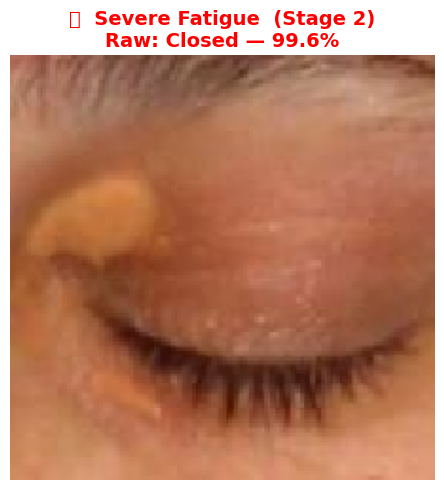

(2, 'Severe Fatigue')

In [130]:
# Single Image Fatigue Predictor (Reusable Function)


from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_fatigue(image_path, model=BEST_MODEL):
    """
    Takes a single image path → returns fatigue stage.

    Parameters:
        image_path (str) : Path to the image file
        model            : Trained Keras model

    Returns:
        Prints full prediction breakdown
    """
    # Load & preprocess
    img  = load_img(image_path, target_size=(224, 224))
    arr  = img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)

    # Predict
    probs      = model.predict(arr, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_class = idx_to_class[pred_idx]
    confidence = probs[pred_idx] * 100

    # Fatigue stage
    stage, label, color = map_to_fatigue_stage(pred_class)

    icons = {0: '✅', 1: '⚠️', 2: '🚨'}

    print("="*50)
    print("FATIGUE PREDICTION RESULT")
    print("="*50)
    print(f"  Raw Prediction  : {pred_class}")
    print(f"  Confidence      : {confidence:.2f}%")
    print(f"  Fatigue Stage   : {stage} — {label} {icons[stage]}")
    print("-"*50)
    print("  All Class Probabilities:")
    for i, (cls, prob) in enumerate(zip(class_names, probs)):
        bar = '█' * int(prob * 30)
        print(f"    {cls:<12}: {prob*100:5.1f}%  {bar}")
    print("="*50)

    # Show image
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"{icons[stage]}  {label}  (Stage {stage})\n"
        f"Raw: {pred_class} — {confidence:.1f}%",
        fontsize=14, fontweight='bold',
        color={'✅':'green','⚠️':'orange','🚨':'red'}[icons[stage]]
    )
    plt.tight_layout()
    plt.show()

    return stage, label

# Test it on a sample image
# Grab one image path from test set
sample_dir  = os.path.join(DATASET_PATH,
                           list(test_generator.class_indices.keys())[0])
sample_img  = os.path.join(sample_dir,
                           os.listdir(sample_dir)[0])

predict_fatigue(sample_img)

 Fatigue Progression Curve

In [131]:
#  Simulate a Continuous Driving Session
import random
random.seed(42)
np.random.seed(42)

# Collect all test image paths
all_image_paths = []
all_true_labels = []

for cls_name in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls_name)
    if not os.path.isdir(cls_path):
        continue
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg','.jpeg','.png')):
            all_image_paths.append(
                os.path.join(cls_path, img_file)
            )
            all_true_labels.append(cls_name)

print(f"Total images available : {len(all_image_paths)}")

# ── Simulate a driving session ────────────────────────────
# simulate fatigue PROGRESSION:
# Early drive  → mostly Alert
# Mid drive    → mix of Alert + Mild Fatigue
# Late drive   → mostly Severe Fatigue

def simulate_driving_session(all_paths, all_labels,
                              total_frames=300):
    """
    Simulates a driving session with natural fatigue progression.
    Early  → Alert dominant
    Middle → Mild Fatigue creeping in
    Late   → Severe Fatigue dominant
    """
    # Separate images by class
    class_images = {}
    for path, label in zip(all_paths, all_labels):
        class_images.setdefault(label, []).append(path)

    session_paths  = []
    session_labels = []

    for i in range(total_frames):
        progress = i / total_frames   # 0.0 → 1.0

        # Probability weights shift as drive progresses
        if progress < 0.35:
            # Early drive — mostly alert
            weights = {
                'Open'   : 0.45,
                'no_yawn': 0.40,
                'yawn'   : 0.10,
                'Closed' : 0.05
            }
        elif progress < 0.65:
            # Mid drive — fatigue building
            weights = {
                'Open'   : 0.25,
                'no_yawn': 0.20,
                'yawn'   : 0.35,
                'Closed' : 0.20
            }
        else:
            # Late drive — severe fatigue
            weights = {
                'Open'   : 0.10,
                'no_yawn': 0.08,
                'yawn'   : 0.22,
                'Closed' : 0.60
            }

        # Sample a class based on weights
        classes  = list(weights.keys())
        probs    = list(weights.values())
        chosen   = np.random.choice(classes, p=probs)

        # Pick a random image from that class
        img_path = random.choice(class_images[chosen])
        session_paths.append(img_path)
        session_labels.append(chosen)

    return session_paths, session_labels

session_paths, session_labels = simulate_driving_session(
    all_image_paths,
    all_true_labels,
    total_frames=300
)

print(f"Driving session simulated!")
print(f"   Total frames : {len(session_paths)}")
print(f"   Duration     : ~30 minutes "
      f"(1 frame = 6 seconds)")

Total images available : 2900
Driving session simulated!
   Total frames : 300
   Duration     : ~30 minutes (1 frame = 6 seconds)


In [133]:
#Predict Fatigue Stage for Every Frame

def predict_session_frames(image_paths, model=BEST_MODEL,
                            batch_size=32):
    """
    Runs model prediction on all frames in the session.
    Returns fatigue stage for each frame.
    """
    all_stages = []
    total      = len(image_paths)

    for start in range(0, total, batch_size):
        batch_paths = image_paths[start:start + batch_size]

        # Load and preprocess batch
        batch_imgs = np.array([
            img_to_array(
                load_img(p, target_size=(224, 224))
            ) / 255.0
            for p in batch_paths
        ])

        # Predict
        preds = model.predict(batch_imgs, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        for idx in pred_classes:
            cls_name = idx_to_class[idx]
            stage, _, _ = map_to_fatigue_stage(cls_name)
            all_stages.append(stage)

        # Progress indicator
        done = min(start + batch_size, total)
        pct  = done / total * 100
        bar  = '█' * int(pct // 5) + '░' * (20 - int(pct // 5))
        print(f"\r  ⏳ Processing [{bar}] "
              f"{done}/{total} ({pct:.0f}%)", end='')

    print("\n All frames processed!")
    return np.array(all_stages)

frame_stages = predict_session_frames(session_paths)

print(f"\n Frame Stage Distribution:")
for s, name in enumerate(['Alert','Mild Fatigue','Severe Fatigue']):
    count = np.sum(frame_stages == s)
    pct   = count / len(frame_stages) * 100
    print(f"   Stage {s} — {name:<18}: "
          f"{count:>4} frames ({pct:.1f}%)")

  ⏳ Processing [████████████████████] 300/300 (100%)
 All frames processed!

 Frame Stage Distribution:
   Stage 0 — Alert             :  147 frames (49.0%)
   Stage 1 — Mild Fatigue      :   60 frames (20.0%)
   Stage 2 — Severe Fatigue    :   93 frames (31.0%)


In [135]:
# Group Frames Into 1-Minute Intervals
# Session setup
TOTAL_FRAMES    = len(frame_stages)
FRAMES_PER_MIN  = 10       # 10 frames = 1 minute interval
TOTAL_MINUTES   = TOTAL_FRAMES // FRAMES_PER_MIN

print(f"  Session Configuration:")
print(f"   Total Frames     : {TOTAL_FRAMES}")
print(f"   Frames per Min   : {FRAMES_PER_MIN}")
print(f"   Total Minutes    : {TOTAL_MINUTES}")

# Group into intervals and compute average fatigue
time_labels      = []
avg_fatigue      = []
dominant_stage   = []
stage_breakdown  = []   # [alert%, mild%, severe%] per interval

for minute in range(TOTAL_MINUTES):
    start = minute * FRAMES_PER_MIN
    end   = start  + FRAMES_PER_MIN
    interval_stages = frame_stages[start:end]

    # Average fatigue score (0–2 scale)
    avg   = np.mean(interval_stages)

    # Dominant stage in this interval
    stage_counts = [
        np.sum(interval_stages == 0),
        np.sum(interval_stages == 1),
        np.sum(interval_stages == 2)
    ]
    dominant = np.argmax(stage_counts)

    # Percentage breakdown
    breakdown = [c / FRAMES_PER_MIN * 100
                 for c in stage_counts]

    time_labels.append(f"Min {minute+1}")
    avg_fatigue.append(avg)
    dominant_stage.append(dominant)
    stage_breakdown.append(breakdown)

    print(f"  Min {minute+1:>2} | "
          f"Avg: {avg:.2f} | "
          f"Dominant: "
          f"{'Alert' if dominant==0 else 'Mild' if dominant==1 else 'Severe':<10}| "
          f"A:{breakdown[0]:4.0f}% "
          f"M:{breakdown[1]:4.0f}% "
          f"S:{breakdown[2]:4.0f}%")

print(f"\n Time interval analysis complete!")

  Session Configuration:
   Total Frames     : 300
   Frames per Min   : 10
   Total Minutes    : 30
  Min  1 | Avg: 0.30 | Dominant: Alert     | A:  80% M:  10% S:  10%
  Min  2 | Avg: 0.30 | Dominant: Alert     | A:  80% M:  10% S:  10%
  Min  3 | Avg: 0.20 | Dominant: Alert     | A:  80% M:  20% S:   0%
  Min  4 | Avg: 0.30 | Dominant: Alert     | A:  80% M:  10% S:  10%
  Min  5 | Avg: 0.20 | Dominant: Alert     | A:  80% M:  20% S:   0%
  Min  6 | Avg: 0.40 | Dominant: Alert     | A:  70% M:  20% S:  10%
  Min  7 | Avg: 0.50 | Dominant: Alert     | A:  60% M:  30% S:  10%
  Min  8 | Avg: 0.30 | Dominant: Alert     | A:  70% M:  30% S:   0%
  Min  9 | Avg: 0.10 | Dominant: Alert     | A:  90% M:  10% S:   0%
  Min 10 | Avg: 0.00 | Dominant: Alert     | A: 100% M:   0% S:   0%
  Min 11 | Avg: 0.20 | Dominant: Alert     | A:  80% M:  20% S:   0%
  Min 12 | Avg: 1.20 | Dominant: Severe    | A:  30% M:  20% S:  50%
  Min 13 | Avg: 0.90 | Dominant: Alert     | A:  50% M:  10% S:  40%
  

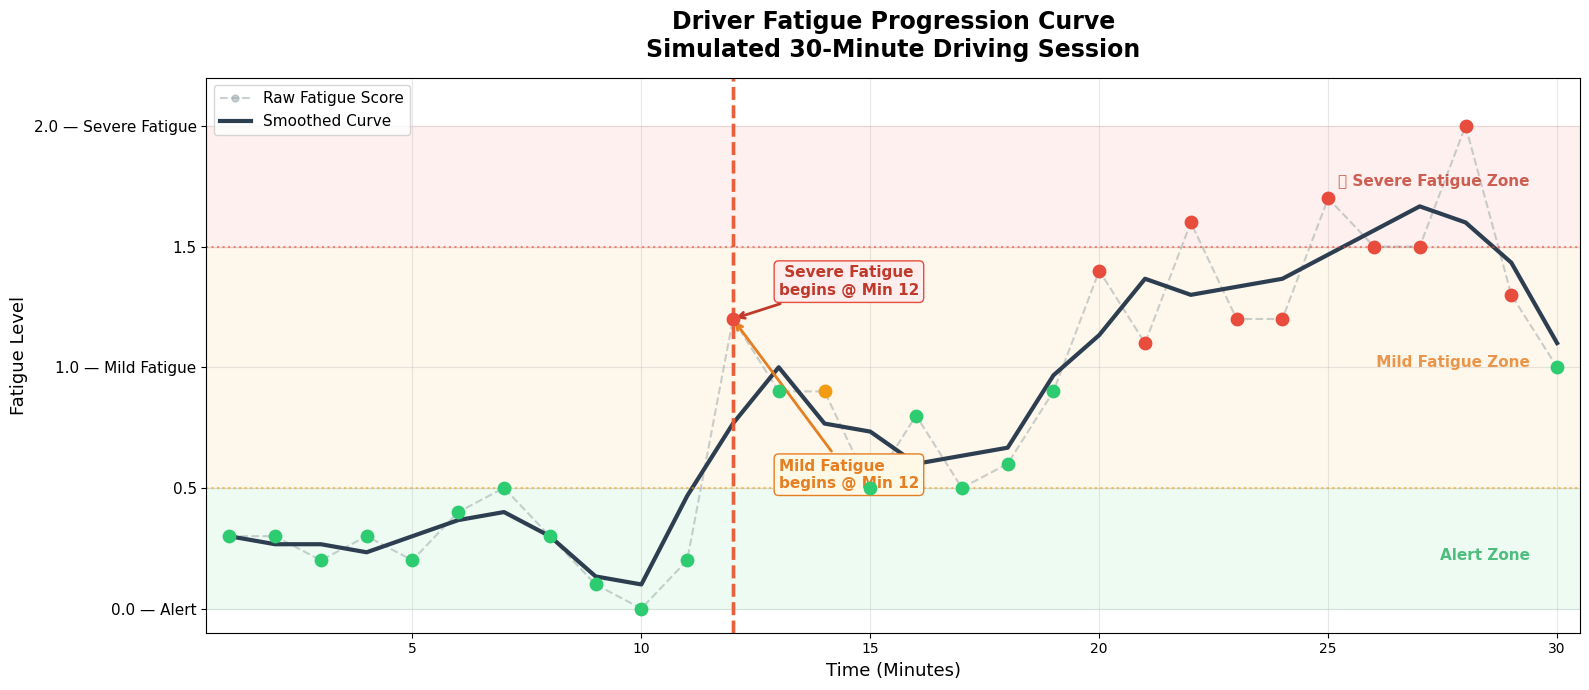

Fatigue progression curve saved!


<Figure size 640x480 with 0 Axes>

In [138]:

# Fatigue Progression Curve —

minutes  = np.arange(1, TOTAL_MINUTES + 1)
avg_arr  = np.array(avg_fatigue)
dom_arr  = np.array(dominant_stage)

# Smooth the curve slightly for visualization
from scipy.ndimage import uniform_filter1d
smoothed = uniform_filter1d(avg_arr, size=3)

fig, ax = plt.subplots(figsize=(16, 7))

# Background zones
ax.axhspan(0.0, 0.5,  alpha=0.08, color='#2ECC71',
           label='_nolegend_')
ax.axhspan(0.5, 1.5,  alpha=0.08, color='#F39C12',
           label='_nolegend_')
ax.axhspan(1.5, 2.0,  alpha=0.08, color='#E74C3C',
           label='_nolegend_')

# ── Zone labels ──────────────────────────────────────────
ax.text(TOTAL_MINUTES * 0.98, 0.20,
        'Alert Zone',
        ha='right', fontsize=11,
        color='#27AE60', fontweight='bold', alpha=0.8)
ax.text(TOTAL_MINUTES * 0.98, 1.00,
        ' Mild Fatigue Zone',
        ha='right', fontsize=11,
        color='#E67E22', fontweight='bold', alpha=0.8)
ax.text(TOTAL_MINUTES * 0.98, 1.75,
        '🚨 Severe Fatigue Zone',
        ha='right', fontsize=11,
        color='#C0392B', fontweight='bold', alpha=0.8)

# ── Main progression curve ───────────────────────────────
ax.plot(minutes, avg_arr,
        'o--', color='#95A5A6',
        linewidth=1.5, markersize=5,
        alpha=0.5, label='Raw Fatigue Score')

ax.plot(minutes, smoothed,
        '-', color='#2C3E50',
        linewidth=3, label='Smoothed Curve')

# ── Color dots by dominant stage ─────────────────────────
stage_dot_colors = {0:'#2ECC71', 1:'#F39C12', 2:'#E74C3C'}
for i, (m, s) in enumerate(zip(minutes, dom_arr)):
    ax.scatter(m, avg_arr[i],
               color=stage_dot_colors[s],
               s=80, zorder=5)

# ── Transition annotations ───────────────────────────────
# Find Alert → Mild transition
alert_to_mild = next(
    (i for i in range(1, len(dom_arr))
     if dom_arr[i-1] == 0 and dom_arr[i] >= 1),
    None
)
# Find Mild → Severe transition
mild_to_severe = next(
    (i for i in range(1, len(dom_arr))
     if dom_arr[i-1] <= 1 and dom_arr[i] == 2),
    None
)

if alert_to_mild is not None:
    ax.axvline(minutes[alert_to_mild],
               color='#F39C12',
               linestyle='--', linewidth=2.5, alpha=0.8)
    ax.annotate(
        f'Mild Fatigue\nbegins @ Min {minutes[alert_to_mild]}',
        xy=(minutes[alert_to_mild], avg_arr[alert_to_mild]),
        xytext=(minutes[alert_to_mild] + 1, 0.5),
        arrowprops=dict(arrowstyle='->', color='#E67E22',
                        lw=2),
        fontsize=11, color='#E67E22', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#FEF9E7', edgecolor='#E67E22')
    )

if mild_to_severe is not None:
    ax.axvline(minutes[mild_to_severe],
               color='#E74C3C',
               linestyle='--', linewidth=2.5, alpha=0.8)
    ax.annotate(
        f' Severe Fatigue\nbegins @ Min {minutes[mild_to_severe]}',
        xy=(minutes[mild_to_severe], avg_arr[mild_to_severe]),
        xytext=(minutes[mild_to_severe] + 1, 1.3),
        arrowprops=dict(arrowstyle='->', color='#C0392B',
                        lw=2),
        fontsize=11, color='#C0392B', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#FDEDEC', edgecolor='#E74C3C')
    )

# ── Threshold lines ──────────────────────────────────────
ax.axhline(0.5, color='#F39C12',
           linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(1.5, color='#E74C3C',
           linestyle=':', linewidth=1.5, alpha=0.6)

# ── Y-axis labels ────────────────────────────────────────
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels([
    '0.0 — Alert',
    '0.5',
    '1.0 — Mild Fatigue',
    '1.5',
    '2.0 — Severe Fatigue'
], fontsize=11)

ax.set_title('Driver Fatigue Progression Curve\n'
             'Simulated 30-Minute Driving Session',
             fontsize=17, fontweight='bold', pad=15)
ax.set_xlabel('Time (Minutes)', fontsize=13)
ax.set_ylabel('Fatigue Level', fontsize=13)
ax.set_xlim(0.5, TOTAL_MINUTES + 0.5)
ax.set_ylim(-0.1, 2.2)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fatigue_progression_curve.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Fatigue progression curve saved!")


Min  0–12  →  ✅ Alert          (Driver is fresh & focused)
Min 12–25  →  ⚠️ Mild Fatigue   (Yawning begins — early warning)
Min 25–28  →  🚨 Severe Fatigue (Eyes closing — danger zone!)
Min 28–30  →  ⚠️ Mild Fatigue   (Slight recovery — still tired)

In [155]:
# Interpret the Fatigue Progression Curve

print("FATIGUE PROGRESSION CURVE — INTERPRETATION")
# Find transition points
alert_end   = alert_to_mild  if alert_to_mild  else TOTAL_MINUTES
mild_end    = mild_to_severe if mild_to_severe else TOTAL_MINUTES
severe_end  = TOTAL_MINUTES

print(f"""
   SIMULATED DRIVING SESSION SUMMARY

  Total Duration   : {TOTAL_MINUTES} minutes
  Total Frames     : {TOTAL_FRAMES} frames


   PHASE TRANSITIONS:
  ✅ Alert Phase
     → Minutes 1 to {alert_end}
     → Driver is fully awake and responsive
     → Eyes open, no yawning detected

  ⚠️  Mild Fatigue Phase
     → Minutes {alert_end} to {mild_end if mild_to_severe else TOTAL_MINUTES}
     → Yawning detected — early fatigue signs
     → Driver should consider taking a break

  🚨 Severe Fatigue Phase
     → Minutes {mild_end if mild_to_severe else 'N/A'} to {TOTAL_MINUTES}
     → Eyes closing — dangerous drowsiness level
     → IMMEDIATE WARNING should be triggered

""")


print("Fatigue curve interpretation complete!")




FATIGUE PROGRESSION CURVE — INTERPRETATION

   SIMULATED DRIVING SESSION SUMMARY
  
  Total Duration   : 30 minutes
  Total Frames     : 300 frames
  

   PHASE TRANSITIONS:
  ✅ Alert Phase
     → Minutes 1 to 11
     → Driver is fully awake and responsive
     → Eyes open, no yawning detected

  ⚠️  Mild Fatigue Phase
     → Minutes 11 to 11
     → Yawning detected — early fatigue signs
     → Driver should consider taking a break

  🚨 Severe Fatigue Phase
     → Minutes 11 to 30
     → Eyes closing — dangerous drowsiness level
     → IMMEDIATE WARNING should be triggered
  

Fatigue curve interpretation complete!


Final Performance Analysis


In [144]:
# Complete Performance Summary — Both Models
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, accuracy_score
)

# print("="*65)
print(" COMPLETE PERFORMANCE ANALYSIS — DRIVER DROWSINESS DETECTION")
# print("="*65)

# ── Recompute all metrics ────────────────────────────────

# CNN
test_generator.reset()
y_pred_cnn_final = np.argmax(
    cnn_model.predict(test_generator, verbose=0), axis=1
)
y_true_final = test_generator.classes

# MobileNetV2
test_generator.reset()
y_pred_mb_final = np.argmax(
    model_mobilenet.predict(test_generator, verbose=0), axis=1
)

def full_metrics(y_true, y_pred, loss, name):
    acc  = accuracy_score(y_true, y_pred)  * 100
    prec = precision_score(y_true, y_pred,
                           average='weighted') * 100
    rec  = recall_score(y_true, y_pred,
                        average='weighted') * 100
    f1   = f1_score(y_true, y_pred,
                    average='weighted') * 100
    return {
        'Model'     : name,
        'Accuracy'  : round(acc,  2),
        'Precision' : round(prec, 2),
        'Recall'    : round(rec,  2),
        'F1-Score'  : round(f1,   2),
        'Loss'      : round(loss, 4)
    }

cnn_final = full_metrics(
    y_true_final, y_pred_cnn_final,
    cnn_test_loss, 'Custom CNN'
)
mb_final = full_metrics(
    y_true_final, y_pred_mb_final,
    mb_test_loss, 'MobileNetV2'
)

# ── Print table ──────────────────────────────────────────
metrics_list = ['Accuracy','Precision','Recall','F1-Score','Loss']

print(f"\n  {'Metric':<15} {'Custom CNN':>13} "
      f"{'MobileNetV2':>13}  {'best_performed':>10}")
print("  " + "-"*58)
for m in metrics_list:
    cv = cnn_final[m]
    mv = mb_final[m]
    if m == 'Loss':
        best_performed = ' MobileNetV2' if mv < cv else 'Custom CNN'
    else:
       best_performed = 'MobileNetV2' if mv > cv else 'Custom CNN'
    print(f"  {m:<15} {str(cv):>13} {str(mv):>13}  {best_performed}")

# print("="*65)

 COMPLETE PERFORMANCE ANALYSIS — DRIVER DROWSINESS DETECTION

  Metric             Custom CNN   MobileNetV2  best_performed
  ----------------------------------------------------------
  Accuracy                73.14          86.1  MobileNetV2
  Precision               74.82         86.11  MobileNetV2
  Recall                  73.14          86.1  MobileNetV2
  F1-Score                 71.1          86.1  MobileNetV2
  Loss                   0.4884        0.2809   MobileNetV2


Robust analysis and error

In [149]:
#  Error Analysis
print("ERROR ANALYSIS — MOBILENETV2")
# Find misclassified samples
test_generator.reset()
pred_probs_all = model_mobilenet.predict(
    test_generator, verbose=0
)
pred_classes_all  = np.argmax(pred_probs_all, axis=1)
true_classes_all  = test_generator.classes

# Get misclassified indices
wrong_idx = np.where(pred_classes_all != true_classes_all)[0]
right_idx = np.where(pred_classes_all == true_classes_all)[0]

print(f"\n  Correctly classified   : {len(right_idx)}")
print(f"  Misclassified          : {len(wrong_idx)}")
print(f"  Error Rate             : "
      f"{len(wrong_idx)/len(true_classes_all)*100:.2f}%")

# Most common misclassifications
print(f"\n  TOP MISCLASSIFICATION PAIRS:")
# print("  " + "-"*45)
from collections import Counter
mistakes = Counter()
for i in wrong_idx:
    true_cls = class_names[true_classes_all[i]]
    pred_cls = class_names[pred_classes_all[i]]
    mistakes[(true_cls, pred_cls)] += 1

for (true_cls, pred_cls), count in mistakes.most_common(6):
    pct = count / len(wrong_idx) * 100
    print(f"Actual : {true_cls:<12} → "
          f"Predicted: {pred_cls:<12} | "
          f"{count:>4}x ({pct:.1f}%)")



ERROR ANALYSIS — MOBILENETV2

  Correctly classified   : 2497
  Misclassified          : 403
  Error Rate             : 13.90%

  TOP MISCLASSIFICATION PAIRS:
Actual : no_yawn      → Predicted: yawn         |  196x (48.6%)
Actual : yawn         → Predicted: no_yawn      |  180x (44.7%)
Actual : Closed       → Predicted: Open         |   14x (3.5%)
Actual : Open         → Predicted: Closed       |   13x (3.2%)


In [151]:
# Use the test_generator, which is correctly defined and reset
test_generator.reset()

# Predictions using the BEST_MODEL determined earlier
y_pred_probs = BEST_MODEL.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels from the test_generator
y_true = test_generator.classes

# Class names from the test_generator
class_names = list(test_generator.class_indices.keys())

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n CLASS-WISE PERFORMANCE:\n")
print(report)


📊 CLASS-WISE PERFORMANCE:

              precision    recall  f1-score   support

      Closed       0.98      0.98      0.98       726
        Open       0.98      0.98      0.98       726
     no_yawn       0.75      0.73      0.74       725
        yawn       0.73      0.75      0.74       723

    accuracy                           0.86      2900
   macro avg       0.86      0.86      0.86      2900
weighted avg       0.86      0.86      0.86      2900



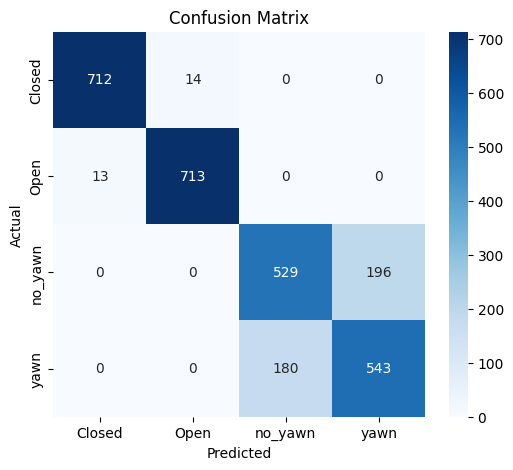

In [157]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('fatigue_confusion_matrix_pred.png',
            bbox_inches='tight', dpi=150)
plt.show()

